In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# 1. Load the dataset
df = pd.read_csv("supermarket_sales.csv")
print(df.columns)

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')


In [13]:
# 2. Display first five records and size
print("First Five Records:")
print(df.head())
print("\nDataset Size:")
print(df.shape)

First Five Records:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1

In [14]:
# 3. Select Total column for revenue analysis
revenue = df["Total"]

In [ ]:
# 4. Check and handle missing values
print("\nMissing Values in Total:")
print(revenue.isnull().sum())
revenue = revenue.dropna()



Missing Values in Total:
0


In [17]:
# 5. Calculate sample size, mean and standard deviation
n = len(revenue)
mean = revenue.mean()
std = revenue.std()
print("\nSample Size:", n)
print("Sample Mean:", mean)
print("Sample Standard Deviation:", std)
# Function to calculate confidence interval
def confidence_interval(confidence):
    standard_error = std / np.sqrt(n)
    margin_error = stats.t.ppf(
        (1 + confidence) / 2,
        n - 1
    ) * standard_error

    lower = mean - margin_error
    upper = mean + margin_error

    return lower, upper



Sample Size: 1000
Sample Mean: 322.966749
Sample Standard Deviation: 245.88533510097187


In [ ]:
# 6. 90% Confidence Interval
ci90 = confidence_interval(0.90)

In [19]:
# 7. 95% Confidence Interval
ci95 = confidence_interval(0.95)

In [20]:
# 8. 99% Confidence Interval
ci99 = confidence_interval(0.99)

In [21]:
# 9. Display confidence intervals in table
ci_table = pd.DataFrame({
    "Confidence Level": ["90%", "95%", "99%"],
    "Lower Bound": [ci90[0], ci95[0], ci99[0]],
    "Upper Bound": [ci90[1], ci95[1], ci99[1]]
})
print("\nConfidence Intervals:")
print(ci_table.round(2))



Confidence Intervals:
  Confidence Level  Lower Bound  Upper Bound
0              90%       310.17       335.77
1              95%       307.71       338.23
2              99%       302.90       343.03


In [22]:
# 10. Compare confidence intervals
print("\nComparison:")
print("90% Confidence Interval:", ci90)
print("95% Confidence Interval:", ci95)
print("99% Confidence Interval:", ci99)


Comparison:
90% Confidence Interval: (np.float64(310.165191817398), np.float64(335.768306182602))
95% Confidence Interval: (np.float64(307.7084118264187), np.float64(338.2250861735813))
99% Confidence Interval: (np.float64(302.8998536663743), np.float64(343.03364433362566))


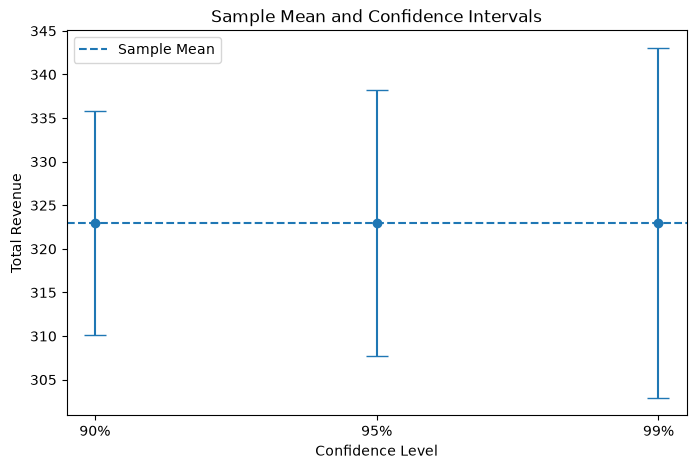

In [ ]:
# 11. Visualization
confidence_levels = ["90%", "95%", "99%"]
lower_bounds = [
    ci90[0],
    ci95[0],
    ci99[0]
]
upper_bounds = [
    ci90[1],
    ci95[1],
    ci99[1]
]
errors_lower = [
    mean - x for x in lower_bounds
]
errors_upper = [
    x - mean for x in upper_bounds
]
plt.figure(figsize=(8, 5))
plt.errorbar(
    confidence_levels,
    [mean, mean, mean],
    yerr=[errors_lower, errors_upper],
    fmt='o',
    capsize=8
)
plt.axhline(
    mean,
    linestyle='--',
    label="Sample Mean"
)
plt.xlabel("Confidence Level")
plt.ylabel("Total Revenue")
plt.title("Sample Mean and Confidence Intervals")
plt.legend()
plt.show()

In [24]:
# 12. Interpretation of 95% CI
print("\nInterpretation of 95% Confidence Interval:")
print(
    f"We are 95% confident that the true population "
    f"mean supermarket revenue lies between "
    f"{ci95[0]:.2f} and {ci95[1]:.2f}."
)


Interpretation of 95% Confidence Interval:
We are 95% confident that the true population mean supermarket revenue lies between 307.71 and 338.23.


In [25]:
# 13. Customer type proportions
customer_type = df["Customer type"]
print("\nCustomer Type Counts:")
print(customer_type.value_counts())
print("\nCustomer Type Proportions:")
proportions = customer_type.value_counts(normalize=True)
print(proportions.round(4))


Customer Type Counts:
Customer type
Member    501
Normal    499
Name: count, dtype: int64

Customer Type Proportions:
Customer type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64


In [27]:
# 14. 95% Confidence Interval for Member customers
member_count = (customer_type == "Member").sum()
total_customers = customer_type.notna().sum()
member_proportion = member_count / total_customers
z = stats.norm.ppf(0.975)
margin = z * np.sqrt(
    member_proportion *
    (1 - member_proportion) /
    total_customers
)
prop_lower = member_proportion - margin
prop_upper = member_proportion + margin
print("\nMember Proportion:")
print(member_proportion)
print("\n95% Confidence Interval for Member Proportion:")
print("Lower Bound:", prop_lower)
print("Upper Bound:", prop_upper)


Member Proportion:
0.501

95% Confidence Interval for Member Proportion:
Lower Bound: 0.47001031036433716
Upper Bound: 0.5319896896356628


In [ ]:
# 15. Business Interpretation
print("\nBusiness Interpretation:")
print(
    f"We are 95% confident that the true population "
    f"proportion of Member customers is between "
    f"{prop_lower * 100:.2f}% and "
    f"{prop_upper * 100:.2f}%."
)


Business Interpretation:
We are 95% confident that the true population proportion of Member customers is between 47.00% and 53.20%.
